✅ Загружено: (6300, 30)
object     17
float64     6
int64       5
bool        2
Name: count, dtype: int64
ОБЗОР ДАТАСЕТА
Строк: 6300
Столбцов: 30

Типы данных:
object     17
float64     6
int64       5
bool        2
Name: count, dtype: int64

Первые 5 строк:
                       id                                           name  \
0  7kr3xZk4yb3YSZ4VFtg2Qt                                       Acoustic   
1  1kJygfS4eoVziBBI93MSYp                                       Acoustic   
2  6lynns69p4zTCRxmmiSY1x                  Here Comes the Sun - Acoustic   
3  1RC9slv335IfLce5vt9KTW                                    Acoustic #3   
4  5o9L8xBuILoVjLECSBi7Vo  My Love Mine All Mine - Acoustic Instrumental   

      genre                        artists  \
0  acoustic                  Billy Raffoul   
1  acoustic                  Billy Raffoul   
2  acoustic  Molly Hocking, Bailey Rushlow   
3  acoustic              The Goo Goo Dolls   
4  acoustic  Guus Dielissen, Casper Esmann   

       

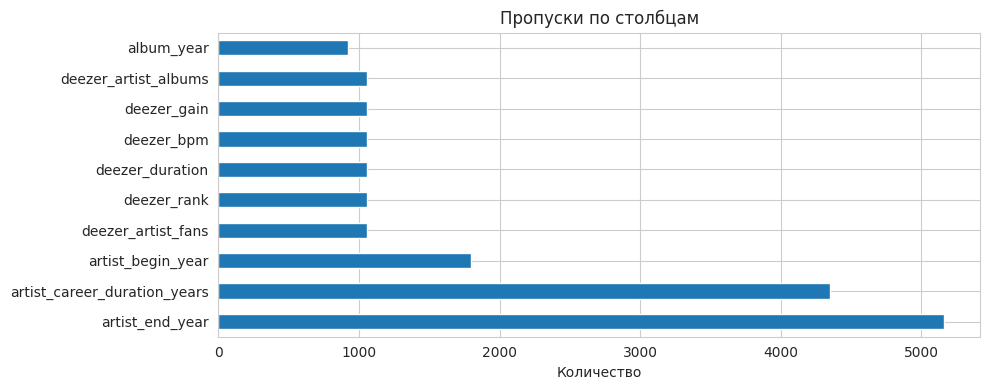

TARGET: popularity
count    6300.000000
mean       30.754762
std        19.948991
min         0.000000
25%        16.000000
50%        29.000000
75%        45.000000
max        90.000000
Name: popularity, dtype: float64


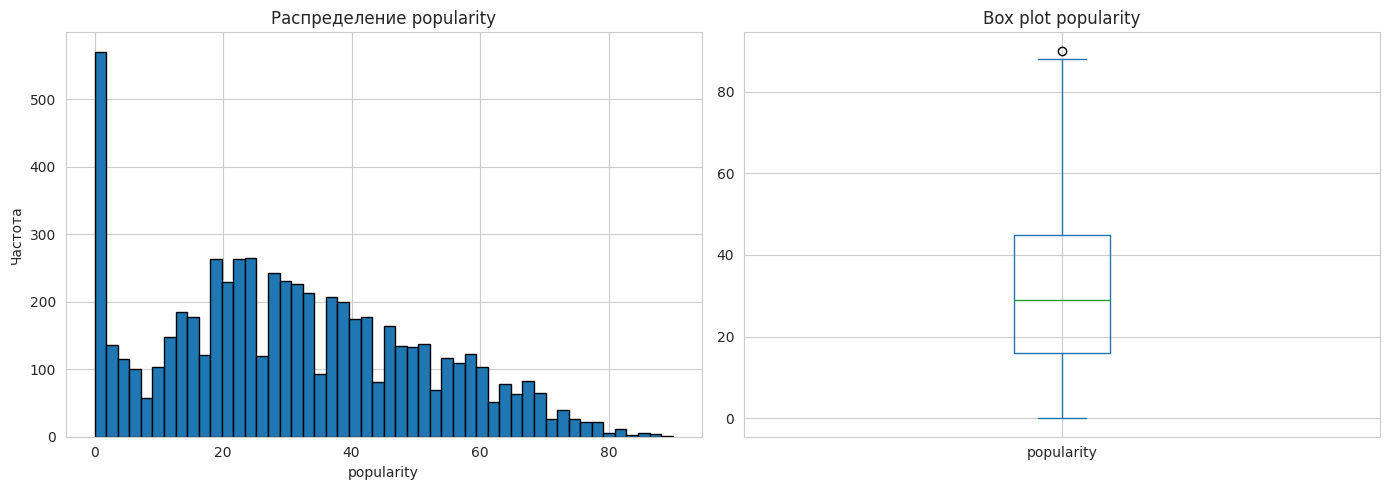


popularity = 0: 470 (7.5%)
Числовые признаки:
                               count           mean            std      min  \
popularity                    6300.0      30.754762      19.948991      0.0   
duration_ms                   6300.0  202847.735238  121029.858319  30060.0   
album_year                    5375.0    2012.012279      12.109806   1935.0   
has_musicbrainz_data          6300.0       0.867143       0.339447      0.0   
album_data_completeness       6300.0       0.573439       0.227852      0.0   
artist_begin_year             4500.0    1971.750444      43.523039   1659.0   
artist_end_year               1139.0    1978.300263      60.514253   1695.0   
has_musicbrainz_artist_data   6300.0       0.900952       0.298750      0.0   
artist_data_completeness      6300.0       0.782751       0.338504      0.0   
artist_career_duration_years  1945.0      27.803599      16.471152      1.0   
deezer_found                  6300.0       0.831905       0.373981      0.0   

    

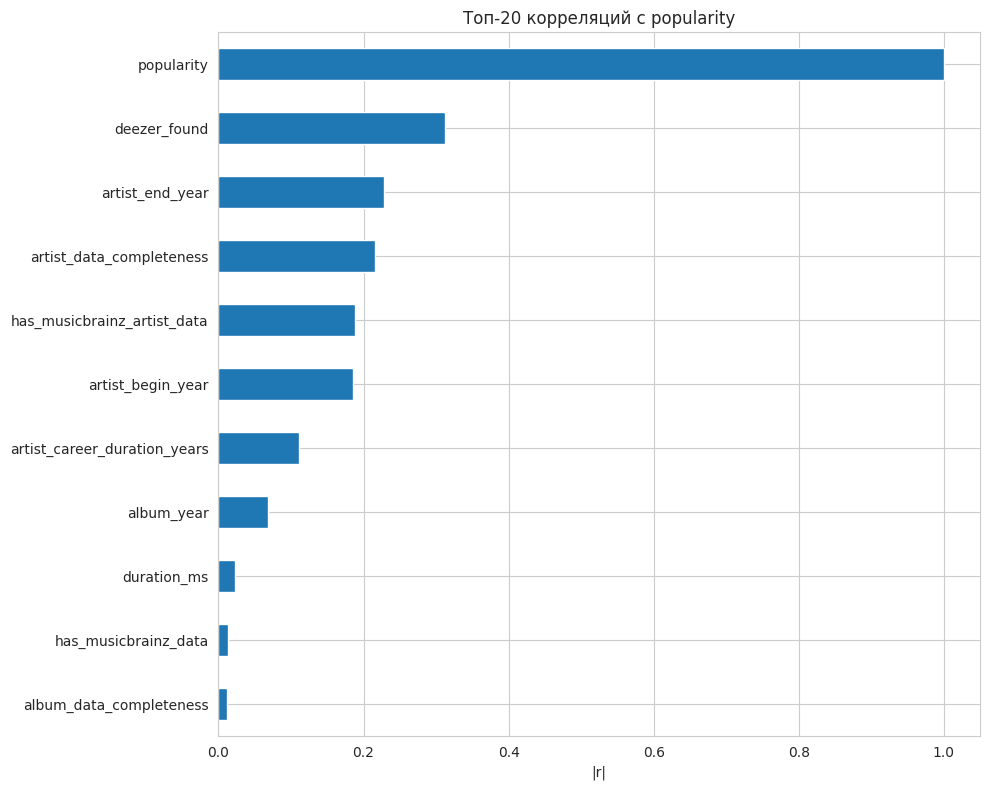

DEEZER
Найдено: 5241 (83.2%)
  deezer_bpm                реальных:  1524 (29.1%), нулей: 3717
  deezer_gain               реальных:  5172 (98.7%), нулей: 69
  deezer_rank               реальных:  5238 (99.9%), нулей: 3
  deezer_artist_fans        реальных:  5201 (99.2%), нулей: 40
  deezer_artist_albums      реальных:  5208 (99.4%), нулей: 33
MUSICBRAINZ
  release_country           unknown:   837 (13.3%)
    Топ-5: {'XW': np.int64(2242), 'US': np.int64(1287), 'unknown': np.int64(837), 'GB': np.int64(318), 'JP': np.int64(190)}
  release_status            unknown:   258 ( 4.1%)
    Топ-5: {'Official': np.int64(5883), 'unknown': np.int64(258), 'Promotion': np.int64(74), 'Bootleg': np.int64(47), 'Pseudo-Release': np.int64(21)}
  artist_type               unknown:   645 (10.2%)
    Топ-5: {'Person': np.int64(3230), 'Group': np.int64(2351), 'unknown': np.int64(645), 'Other': np.int64(41), 'Character': np.int64(17)}
  artist_country            unknown:  1661 (26.4%)
    Топ-5: {'US': np.int64

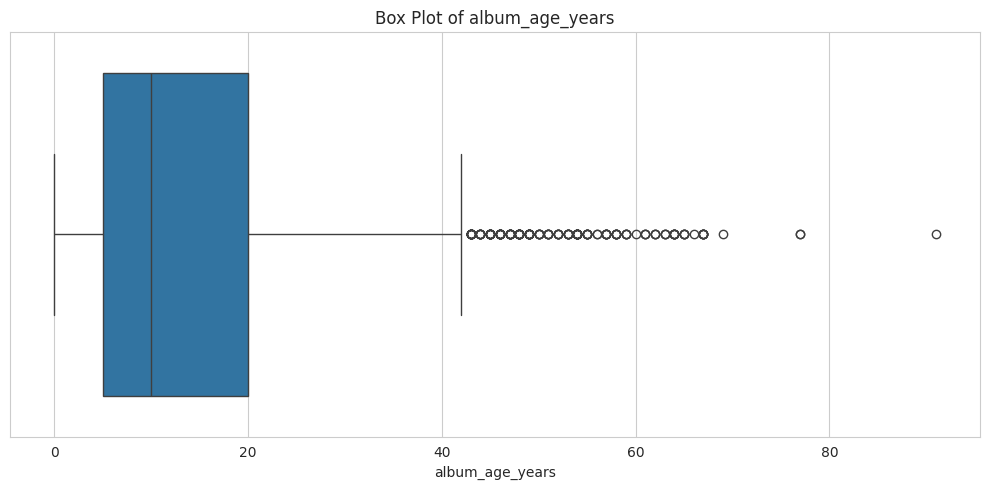


album_age_years:
count    5375.000000
mean       13.987721
std        12.109806
min         0.000000
25%         5.000000
50%        10.000000
75%        20.000000
max        91.000000
Name: album_age_years, dtype: float64

Распределение по десятилетиям:
decade
1930       1
1940       2
1950       7
1960      37
1970      78
1980     179
1990     504
2000     912
2010    1763
2020    1892
Name: count, dtype: Int64


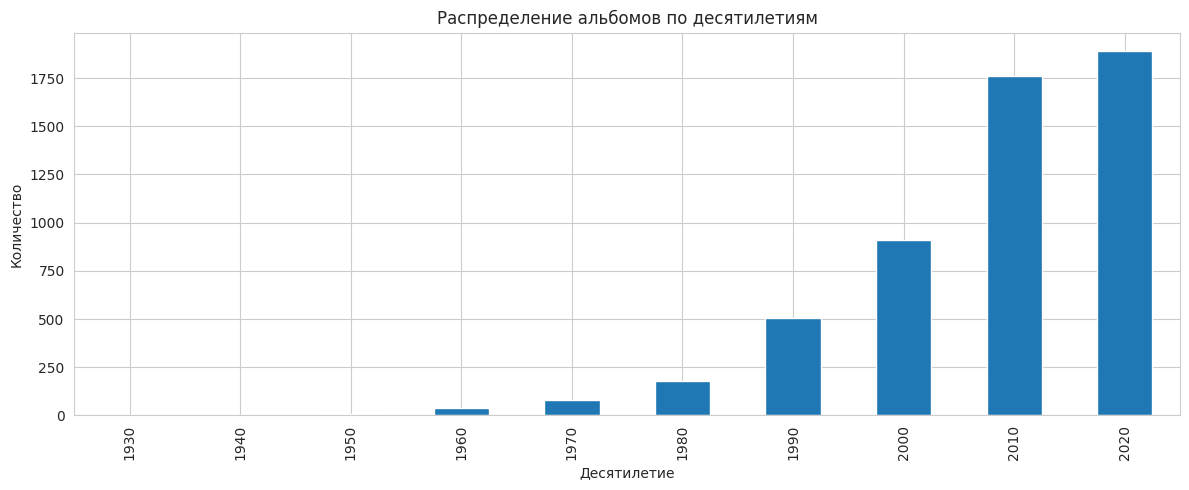


⚠️ Подозрительных 'Piano' 1959: 3
       artists  album_year deezer_bpm deezer_rank
4277  Papatriz      1959.0      114.5      140704
4281   Maiteau      1959.0      119.8       57505
4285  MessKher      1959.0      100.6       87076

✅ 02_eda ЗАВЕРШЁН
{
  "n_rows": 6300,
  "n_cols": 32,
  "target_mean": 30.754761904761907,
  "target_median": 29.0,
  "target_std": 19.94899078235046,
  "target_zero_pct": 0.0746031746031746,
  "deezer_found_pct": 0.8319047619047619,
  "album_year_missing_pct": 0.14682539682539683,
  "artist_begin_missing_pct": 0.2857142857142857
}


In [2]:
# ============================================================
# 02_eda.ipynb
# Разведочный анализ данных
# ============================================================
# Время работы: ~2 минуты
# Входные данные: data/01_raw_enriched.pkl
# ============================================================

# @title 2.1. Импорты и загрузка
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import json
import os

os.makedirs('results/figures', exist_ok=True)
os.makedirs('data', exist_ok=True)

# Настройки визуализации
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

df = pd.read_pickle('data/01_raw_enriched.pkl')
print(f"✅ Загружено: {df.shape}")
print(df.dtypes.value_counts())

# @title 2.2. Первичный обзор
print("=" * 60)
print("ОБЗОР ДАТАСЕТА")
print("=" * 60)
print(f"Строк: {len(df)}")
print(f"Столбцов: {len(df.columns)}")
print(f"\nТипы данных:")
print(df.dtypes.value_counts())

print("\nПервые 5 строк:")
print(df.head())

# @title 2.3. Пропуски
missing = df.isna().sum().sort_values(ascending=False)
missing = missing[missing > 0]
print(f"\nСтолбцов с пропусками: {len(missing)}")
print(missing)

if len(missing) > 0:
    plt.figure(figsize=(10, max(4, len(missing) * 0.3)))
    missing.plot(kind='barh')
    plt.title('Пропуски по столбцам')
    plt.xlabel('Количество')
    plt.tight_layout()
    plt.savefig('results/figures/eda_missing.png', dpi=120)
    plt.show()

# @title 2.4. Целевая переменная
print("=" * 60)
print("TARGET: popularity")
print("=" * 60)
print(df['popularity'].describe())

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

df['popularity'].hist(bins=50, ax=axes[0], edgecolor='black')
axes[0].set_title('Распределение popularity')
axes[0].set_xlabel('popularity')
axes[0].set_ylabel('Частота')

df['popularity'].plot(kind='box', ax=axes[1])
axes[1].set_title('Box plot popularity')

plt.tight_layout()
plt.savefig('results/figures/eda_popularity.png', dpi=120)
plt.show()

n_zero = (df['popularity'] == 0).sum()
print(f"\npopularity = 0: {n_zero} ({n_zero/len(df):.1%})")

# @title 2.5. Числовые признаки: describe
num_cols = df.select_dtypes(include=[np.number]).columns
print("Числовые признаки:")
print(df[num_cols].describe().T)

# @title 2.6. Корреляции с popularity
corr = df[num_cols].corrwith(df['popularity']).abs().sort_values(ascending=False)
print("\nТоп-20 корреляций с popularity:")
print(corr.head(20))

plt.figure(figsize=(10, 8))
corr.head(20).plot(kind='barh')
plt.gca().invert_yaxis()
plt.title('Топ-20 корреляций с popularity')
plt.xlabel('|r|')
plt.tight_layout()
plt.savefig('results/figures/eda_correlations.png', dpi=120)
plt.show()

# @title 2.7. Deezer-признаки: заполненность
if 'deezer_found' in df.columns:
    found = df['deezer_found'] == 1
    print("=" * 60)
    print("DEEZER")
    print("=" * 60)
    print(f"Найдено: {found.sum()} ({found.mean():.1%})")

    for col in ['deezer_bpm', 'deezer_gain', 'deezer_rank',
                'deezer_artist_fans', 'deezer_artist_albums']:
        if col in df.columns:
            n_zero = (df.loc[found, col] == 0).sum()
            n_valid = found.sum() - n_zero
            print(f"  {col:25} реальных: {n_valid:5} "
                  f"({n_valid/found.sum():5.1%}), нулей: {n_zero}")

# @title 2.8. MusicBrainz: заполненность
print("=" * 60)
print("MUSICBRAINZ")
print("=" * 60)

for col in ['release_country', 'release_status', 'artist_type', 'artist_country']:
    if col in df.columns:
        n_unknown = (df[col] == 'unknown').sum()
        print(f"  {col:25} unknown: {n_unknown:5} ({n_unknown/len(df):5.1%})")
        print(f"    Топ-5: {dict(df[col].value_counts().head(5))}")

# @title 2.9. Топ-10 старых альбомов (проверка аномалий)
import datetime
current_year = datetime.datetime.now().year
df['album_age_years'] = current_year - df['album_year']

print("\n" + "=" * 60)
print("АНОМАЛИИ: Топ-10 старых альбомов")
print("=" * 60)
print(df.nlargest(10, 'album_age_years')[
    ['artists', 'album', 'album_year', 'album_age_years']
].to_string())

# @title 2.10. Boxplot album_age_years
plt.figure(figsize=(10, 5))
sns.boxplot(x=df['album_age_years'])
plt.title('Box Plot of album_age_years')
plt.tight_layout()
plt.savefig('results/figures/eda_album_age.png', dpi=120)
plt.show()

print("\nalbum_age_years:")
print(df['album_age_years'].describe())

# @title 2.11. Распределение по десятилетиям
df['decade'] = (df['album_year'] // 10 * 10).astype('Int64')
decade_counts = df['decade'].value_counts().sort_index()
print("\nРаспределение по десятилетиям:")
print(decade_counts)

plt.figure(figsize=(12, 5))
decade_counts.plot(kind='bar')
plt.title('Распределение альбомов по десятилетиям')
plt.xlabel('Десятилетие')
plt.ylabel('Количество')
plt.tight_layout()
plt.savefig('results/figures/eda_decades.png', dpi=120)
plt.show()

# @title 2.12. Проверка аномалий MusicBrainz (Piano 1959)
if 'album' in df.columns:
    suspicious = df[(df['album'] == 'Piano') & (df['album_year'] == 1959)]
    if len(suspicious) > 0:
        print(f"\n⚠️ Подозрительных 'Piano' 1959: {len(suspicious)}")
        print(suspicious[['artists', 'album_year',
                          'deezer_bpm', 'deezer_rank']].to_string())
    else:
        print("\n✅ Подозрительных 'Piano' 1959 нет")

# @title 2.13. Сохранение EDA-summary
eda_summary = {
    'n_rows': int(len(df)),
    'n_cols': int(len(df.columns)),
    'target_mean': float(df['popularity'].mean()),
    'target_median': float(df['popularity'].median()),
    'target_std': float(df['popularity'].std()),
    'target_zero_pct': float((df['popularity'] == 0).mean()),
    'deezer_found_pct': float((df.get('deezer_found', 0) == 1).mean()),
    'album_year_missing_pct': float(df['album_year'].isna().mean()),
    'artist_begin_missing_pct': float(df['artist_begin_year'].isna().mean()),
}

with open('data/02_eda_summary.json', 'w') as f:
    json.dump(eda_summary, f, indent=2)

print(f"\n{'=' * 60}")
print(f"✅ 02_eda ЗАВЕРШЁН")
print(f"{'=' * 60}")
print(json.dumps(eda_summary, indent=2))